# Day 1 (R parallel): the same complexity profile with the `economiccomplexity` package

This is the R companion to the Python notebook. The Python version builds Morocco's complexity profile by hand, one line of matrix algebra at a time. Here we hand the same five steps to the standard R package, `economiccomplexity`, and check that the package agrees with what you built by hand and with WIPO. The point is not to learn a second language today. It is to see that the index you assembled from scratch is the index a maintained package computes, so the method is trustworthy rather than a black box.

We follow the same skeleton, Normalize then Benchmark then Binarize then Count then Iterate, and we reuse the same `COUNTRY`, `COMPARATORS`, and `YEAR` knobs. Edit them at the top to point the notebook at your own country.

## 0. Setup: load the data packet

We load the same packet the Python notebook uses. If it is missing, we stop right away and name the folder you need.

In [1]:
suppressMessages({
  library(arrow) # read the packet's .parquet files
  library(dplyr) # filter, select, group, summarise
  library(tidyr) # reshape long and wide
  library(readr) # read_csv for the reference tables
  library(ggplot2) # the one scatter at the end
  library(economiccomplexity) # balassa_index() and complexity_measures()
})

# --- The ONE place you edit to make this notebook about your own country. ------
# Codes are ISO 3166-1 alpha-2 (two letters). MA = Morocco, EG = Egypt,
# TN = Tunisia, KR = Republic of Korea. See reference/units.csv.
COUNTRY <- "MA" # the focus country (Morocco)
COMPARATORS <- c("EG", "TN", "KR") # Egypt, Tunisia (MENA) + Korea (frontier)
YEAR <- 2023 # latest year in the packet
# -------------------------------------------------------------------------------

# Resolve the packet path relative to this notebook, so it runs from a clean
# checkout regardless of where the repo lives on disk.
PACKET <- normalizePath(
  file.path("..", "..", "data", "processed", "morocco_data_packet"),
  mustWork = FALSE
)

# Fail LOUD if the data is not here. The packet is distributed via a shared link
# (it is too large for git), so a missing packet is the most common first-run
# problem. Name the exact folder the learner must download.
if (!dir.exists(PACKET)) {
  stop(
    "Data packet not found at: ", PACKET, "\n",
    "Download 'morocco_data_packet' from the shared course link and unzip it ",
    "into data/processed/ so this path resolves. The notebook cannot run ",
    "without it."
  )
}
cat("Packet found:", PACKET, "\n")
cat("Focus country:", COUNTRY, "| comparators:", paste(COMPARATORS, collapse = ", "), "| year:", YEAR, "\n")

Packet found: /Users/shg309/Library/CloudStorage/Dropbox-Personal/Education/hks_cid_growth_lab/misc/morocco_summer_school/data/processed/morocco_data_packet 


Focus country: MA | comparators: EG, TN, KR | year: 2023 


We use the Production and exports dimension today, the same trade table as the Python notebook. `read.csv` reads the small reference tables, and we keep the original column names with spaces intact so the codes line up with the packet.

In [2]:
# Raw export VALUE (current USD) per country x product x year, plus product labels.
exports <- read_parquet(file.path(PACKET, "exports", "outputs.parquet"))
fields <- read.csv(
  file.path(PACKET, "reference", "fields.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)
units <- read.csv(
  file.path(PACKET, "reference", "units.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)

cat("exports columns:", paste(names(exports), collapse = ", "), "\n")
cat("exports rows:", format(nrow(exports), big.mark = ","), "\n")
head(exports, 3)

exports columns: Period, Unit, Dimension, Field ID, Outputs, Outputs (Fractional), Population 


exports rows: 3,786,766 


Period,Unit,Dimension,Field ID,Outputs,Outputs (Fractional),Population
<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
2001,UY,P,P - 8448,175351.639,175351.639,3300939
2001,UY,P,P - 8450,2255.253,2255.253,3300939
2001,UY,P,P - 8447,50301.422,50301.422,3300939


## Warm-up: the whole pipeline on a toy table

We run the package on the morning lecture's toy example first, three countries and four products with the same raw export values, small enough to check by eye. `balassa_index()` wants a long table of country, product, value, so we reshape the toy into that shape and let the package do the Normalize, Benchmark, and Binarize steps. Then we count diversity and ubiquity ourselves, since those are just row and column sums.

In [3]:
# The morning lecture's toy example (three countries x four products of raw export
# values), written one country per row so it reads like the printed table.
toy <- tribble(
  ~country, ~Wheat, ~Textiles, ~Motorcycles, ~`Cell phones`,
  "Country A", 10, 40, 100, 300,
  "Country B", 150, 100, 10, 0,
  "Country C", 20, 200, 1, 0
)

# balassa_index() reads a LONG table (one row per country-product), so we pivot to
# long and drop the zeros (a country that does not export a product has no row).
toy_long <- toy %>%
  pivot_longer(-country, names_to = "product", values_to = "value") %>%
  filter(value > 0)

# discrete = FALSE returns the continuous RCA; discrete = TRUE binarizes at the
# Balassa cutoff of 1 to give Mcp. These are the same two calls we make on the
# real data below.
toy_prods <- c("Wheat", "Textiles", "Motorcycles", "Cell phones")
toy_rca <- balassa_index(toy_long, discrete = FALSE, country = "country", product = "product", value = "value")
toy_mcp <- balassa_index(toy_long, discrete = TRUE, cutoff = 1, country = "country", product = "product", value = "value")

# Count across each row for diversity, down each column for ubiquity.
toy_diversity <- rowSums(toy_mcp)
toy_ubiquity <- colSums(toy_mcp)

cat("RCA (share / world share):\n")
print(round(toy_rca[toy$country, toy_prods], 2))
cat("\nMcp (1 where RCA > 1):\n")
print(toy_mcp[toy$country, toy_prods])
cat("\ndiversity (products per country):\n")
print(toy_diversity[toy$country])
cat("ubiquity (countries per product):\n")
print(toy_ubiquity[toy_prods])

RCA (share / world share):


          Wheat Textiles Motorcycles Cell phones
Country A  0.11     0.24        1.86        2.07
Country B  2.98     1.05        0.32        0.00
Country C  0.47     2.48        0.04        0.00



Mcp (1 where RCA > 1):


          Wheat Textiles Motorcycles Cell phones
Country A     0        0           1           1
Country B     1        1           0           0
Country C     0        1           0           0



diversity (products per country):


Country A Country B Country C 
        2         2         1 


ubiquity (countries per product):


      Wheat    Textiles Motorcycles Cell phones 
          1           2           1           1 


Country A and Country B each export two products competitively, yet A makes the rarer motorcycles and cell phones while B makes wheat and textiles. Equal diversity does not mean equal sophistication, which is what the index below is for. The real matrix runs the same three package calls at 191 countries by 862 products.

## 1. Normalize, Benchmark, Binarize: RCA and Mcp from the package

We reshape the real export table to long form and hand it to `balassa_index()` twice, once for the continuous RCA and once for the binary Mcp. The package does inside one call what the Python notebook spells out as three steps: divide each country by its own basket (shares), divide by the world's share of each product (RCA, due to Balassa), then threshold at 1.

In [4]:
# One year of trade, long form: country (Unit), product (Field ID), value (Outputs).
year_long <- exports %>%
  filter(Period == YEAR) %>%
  select(Unit, `Field ID`, Outputs)
cat("countries:", n_distinct(year_long$Unit), "| products:", n_distinct(year_long$`Field ID`), "\n")

# RCA above 1 means the country is more specialized in the product than the world
# average. Mcp is 1 where RCA > 1, the yes-or-no "does this country make this
# product competitively" that the rest of the day is built on.
rca <- balassa_index(year_long, discrete = FALSE, country = "Unit", product = "Field ID", value = "Outputs")
mcp <- balassa_index(year_long, discrete = TRUE, cutoff = 1, country = "Unit", product = "Field ID", value = "Outputs")

cat(COUNTRY, "RCA for Passenger Cars (P - 8703):", round(rca[COUNTRY, "P - 8703"], 2), "\n")
cat("Top-5 products by RCA for", COUNTRY, ":\n")
print(round(sort(rca[COUNTRY, ], decreasing = TRUE)[1:5], 2))

# Self-check: Morocco over-specializes in Passenger Cars, so RCA there is above 1.
if (!(rca[COUNTRY, "P - 8703"] > 1)) {
  stop("Morocco's RCA in Passenger Cars should be > 1. Check the country/product arguments to balassa_index().")
}
cat("OK: RCA in Passenger Cars is", round(rca[COUNTRY, "P - 8703"], 2), "\n")

countries: 191 | products: 862 


MA RCA for Passenger Cars (P - 8703): 3.42 


Top-5 products by RCA for MA :


P - 3103 P - 2809 P - 2510 P - 0708 P - 3105 
  114.97   100.72    92.27    76.59    72.07 


OK: RCA in Passenger Cars is 3.42 


## 2. Count: diversity and ubiquity

We read Mcp two ways. Summing across a country's row gives diversity, the number of products it makes competitively. Summing down a product's column gives ubiquity, the number of countries that make it. These two counts are the raw material of the index.

In [5]:
diversity <- rowSums(mcp) # products per country
ubiquity <- colSums(mcp) # countries per product

cat(COUNTRY, "diversity (products made competitively):", diversity[COUNTRY], "\n")
cat("Most diversified countries:\n")
print(sort(diversity, decreasing = TRUE)[1:5])

# Self-check: Morocco's diversity must match the Python notebook's headline count
# of 129 exactly. Same data, same RCA > 1 rule, so this is an exact match, not an
# approximation.
if (diversity[COUNTRY] != 129) {
  stop(
    "Morocco's diversity is ", diversity[COUNTRY], " but the Python notebook prints 129. ",
    "The package's RCA > 1 rule should reproduce the by-hand count exactly."
  )
}
# And a diversified economy (Morocco) beats a concentrated one (Chad, TD).
if (!(diversity[COUNTRY] > diversity["TD"])) {
  stop("A diversified economy (Morocco) should be more diverse than a concentrated one (Chad).")
}
cat("OK: Morocco's diversity is 129, matching the Python notebook, and MA > TD.\n")

MA diversity (products made competitively): 129 


Most diversified countries:


 CN  IT  ES  DE  TR 
414 385 375 373 351 


OK: Morocco's diversity is 129, matching the Python notebook, and MA > TD.


### Diversity versus average ubiquity

Each point is a country: its diversity against the average ubiquity of the products it makes competitively. The downward tilt is the empirical regularity the method of reflections builds on. More diversified countries reach into the rarer, less ubiquitous products.

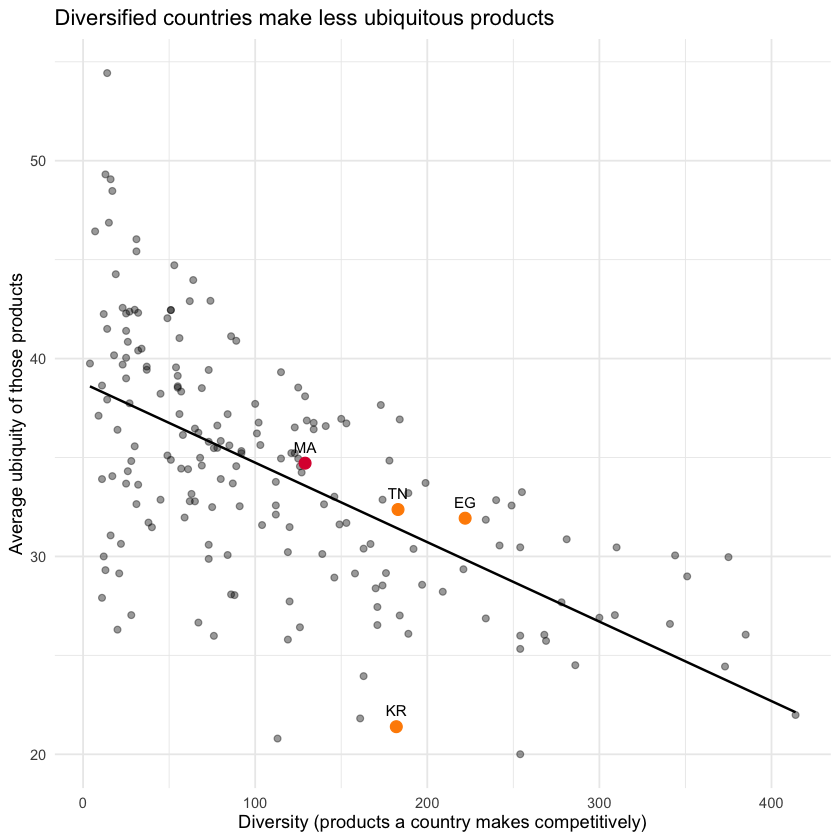

In [6]:
# For each country, the mean ubiquity of the products it makes competitively
# (the columns where Mcp == 1 in that country's row).
avg_ubi_of_country <- apply(mcp, 1, function(row) {
  made <- row == 1
  if (any(made)) mean(ubiquity[made]) else NA_real_
})
div_ubi <- data.frame(
  code = names(diversity),
  diversity = as.numeric(diversity),
  avg_ubiquity = as.numeric(avg_ubi_of_country),
  stringsAsFactors = FALSE
)
div_ubi <- div_ubi[!is.na(div_ubi$avg_ubiquity), ]

du_highlight <- div_ubi[div_ubi$code %in% c(COUNTRY, COMPARATORS), ]
ggplot(div_ubi, aes(diversity, avg_ubiquity)) +
  geom_point(alpha = 0.4, size = 1.6) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "black", linewidth = 0.7) +
  geom_point(data = du_highlight, aes(color = code == COUNTRY), size = 3, show.legend = FALSE) +
  geom_text(data = du_highlight, aes(label = code), vjust = -1, size = 3.2) +
  scale_color_manual(values = c(`TRUE` = "#DC143C", `FALSE` = "darkorange")) +
  labs(
    x = "Diversity (products a country makes competitively)",
    y = "Average ubiquity of those products",
    title = "Diversified countries make less ubiquitous products"
  ) +
  theme_minimal()

## 3. Iterate: ECI and PCI from `complexity_measures()`

We combine diversity and ubiquity into one number per country (ECI) and one per product (PCI). The Python notebook hand-rolls the method of reflections and pulls out the second eigenvector, then sign-fixes and standardizes by hand. The package does all of that inside `complexity_measures()`. We ask for `method = "eigenvalues"`, which is the eigenvector route the Python notebook takes, so the two should line up closely.

In [7]:
# method = "eigenvalues" takes the second eigenvector of the reflection operator,
# the same object the Python notebook builds by hand. The package standardizes the
# result and prints a note when it flips the sign so ECI rises with diversity, the
# one step the Python notebook makes you author yourself.
cm <- complexity_measures(mcp, method = "eigenvalues")
eci <- cm$complexity_index_country
pci <- cm$complexity_index_product

cat(COUNTRY, "ECI (trade-only, package):", round(eci[COUNTRY], 3), "\n")
cat("Highest-PCI products:\n")
print(round(sort(pci, decreasing = TRUE)[1:5], 3))

# Self-check: ECI is standardized (mean 0, sd 1) and rises with diversity (the
# sign is anchored the same way the Python notebook anchors it).
if (abs(mean(eci)) > 1e-6 || abs(sd(eci) - 1) > 1e-2) {
  stop("ECI should be standardized (mean 0, sd 1).")
}
if (!(cor(diversity[names(eci)], eci) > 0)) {
  stop("ECI should rise with diversity. The sign correction may have gone the wrong way.")
}
cat("OK: ECI is standardized and rises with diversity (corr =", round(cor(diversity[names(eci)], eci), 3), ").\n")

applying sign correction to product index...



MA ECI (trade-only, package): -0.469 


Highest-PCI products:


P - 2841 P - 7506 P - 9012 P - 2843 P - 2931 
   3.222    2.398    1.979    1.963    1.927 


OK: ECI is standardized and rises with diversity (corr = 0.681 ).


## 4. Validate against WIPO

We run the same external check the Python notebook runs. WIPO publishes its own binary capability matrix and its own product complexity index, computed with a different presence rule and across all four dimensions rather than trade alone. Our package numbers should agree strongly but not perfectly, and the gap is the lesson: methodology is a choice, not a bug.

In [8]:
# Compare our Mcp to WIPO's binary capability matrix for the same year.
wipo_cap <- read_parquet(file.path(PACKET, "exports", "capabilities.parquet")) %>%
  filter(Period == YEAR)
wipo_mcp <- wipo_cap %>%
  select(Unit, `Field ID`, `Innovation Capability (Binary)`) %>%
  pivot_wider(names_from = `Field ID`, values_from = `Innovation Capability (Binary)`, values_fill = FALSE)
wipo_mat <- as.matrix(wipo_mcp[, -1]) * 1 # logical to 0/1
rownames(wipo_mat) <- wipo_mcp$Unit

shared_c <- intersect(rownames(mcp), rownames(wipo_mat))
shared_p <- intersect(colnames(mcp), colnames(wipo_mat))
agreement <- mean(mcp[shared_c, shared_p] == wipo_mat[shared_c, shared_p])
cat("Our Mcp agrees with WIPO's binary capability on", sprintf("%.1f%%", 100 * agreement), "of cells.\n")

Our Mcp agrees with WIPO's binary capability on 92.6% of cells.


In [9]:
# Compare our PCI to WIPO's "Capability Complexity Index" (the PCI analogue) by
# rank correlation, since the methods differ and exact equality is not expected.
wipo_pci <- read_parquet(file.path(PACKET, "exports", "field_complexities.parquet")) %>%
  filter(Period == YEAR)
wipo_pci_v <- setNames(wipo_pci$`Capability Complexity Index`, wipo_pci$`Field ID`)

common_p <- intersect(names(pci), names(wipo_pci_v))
pci_rho <- cor(pci[common_p], wipo_pci_v[common_p], method = "spearman")
cat("Spearman(our PCI, WIPO PCI) =", round(pci_rho, 3), "over", length(common_p), "products.\n")

# Self-check: strong but IMPERFECT rank agreement, the same loose band the Python
# notebook uses on purpose. Asserting exact equality here would contradict the
# lesson that methods differ.
if (!(pci_rho > 0.6)) {
  stop("Our PCI should correlate strongly with WIPO's (Spearman > 0.6). Re-check the eigenvector step.")
}
if (!(pci_rho < 0.999)) {
  stop("The correlation should NOT be perfect. Our RCA > 1 rule and trade-only index differ from WIPO's method.")
}
cat("OK: strong but imperfect agreement (Spearman =", round(pci_rho, 3), "), as expected.\n")

Spearman(our PCI, WIPO PCI) = 0.923 over 862 products.


OK: strong but imperfect agreement (Spearman = 0.923 ), as expected.


## 5. Reconcile with the Python hand-roll

The real test of this notebook is whether the package reproduces the numbers you built by hand in the Python session. When the companion file `day1_python_reference.csv` is present (the Python notebook's ECI and PCI, saved alongside this one), we load it and rank-correlate. Unlike the WIPO comparison, this is the same method on the same data, so we expect near-perfect agreement rather than a methodology gap.

In [10]:
py_ref_path <- "day1_python_reference.csv"
if (file.exists(py_ref_path)) {
  py_ref <- read_csv(py_ref_path, show_col_types = FALSE)
  py_eci <- setNames(py_ref$value[py_ref$kind == "eci"], py_ref$id[py_ref$kind == "eci"])
  py_pci <- setNames(py_ref$value[py_ref$kind == "pci"], py_ref$id[py_ref$kind == "pci"])

  ce <- intersect(names(eci), names(py_eci))
  cp <- intersect(names(pci), names(py_pci))
  eci_rho <- cor(eci[ce], py_eci[ce], method = "spearman")
  pci_rho_py <- cor(pci[cp], py_pci[cp], method = "spearman")
  cat("Spearman(R ECI, Python ECI) =", round(eci_rho, 4), "over", length(ce), "countries.\n")
  cat("Spearman(R PCI, Python PCI) =", round(pci_rho_py, 4), "over", length(cp), "products.\n")
  cat("Gap in Morocco's standardized ECI (R minus Python):", round(eci[COUNTRY] - py_eci[COUNTRY], 4), "\n")
  cat("Largest ECI gap across all countries:", round(max(abs(eci[ce] - py_eci[ce])), 4), "\n")

  # Self-check: the package must reproduce the by-hand index. Same method, same
  # data, so the ranks should agree almost perfectly.
  if (!(eci_rho > 0.9 && pci_rho_py > 0.9)) {
    stop("The package ECI/PCI should rank-correlate above 0.9 with the Python hand-roll. If not, the method or the matrix differs.")
  }
  cat("OK: the package reproduces the Python hand-roll (both rank correlations > 0.9).\n")
} else {
  cat("Companion file", py_ref_path, "not found, so the Python cross-check is skipped.\n")
  cat("The WIPO validation above still runs from the packet alone.\n")
}

Spearman(R ECI, Python ECI) = 1 over 190 countries.
Spearman(R PCI, Python PCI) = 1 over 862 products.
Gap in Morocco's standardized ECI (R minus Python): 0.0012 
Largest ECI gap across all countries: 0.0066 
OK: the package reproduces the Python hand-roll (both rank correlations > 0.9).


## 6. Does complexity track prosperity?

We connect the index to something a policymaker cares about. We plot each country's ECI against its GDP per capita, flag Morocco and its comparators, and read where Morocco sits relative to the fitted line.

Correlation(log GDP per capita, ECI) = 0.697 


OLS slope (ECI on log GDP per capita) = 0.6 | R^2 = 0.485 


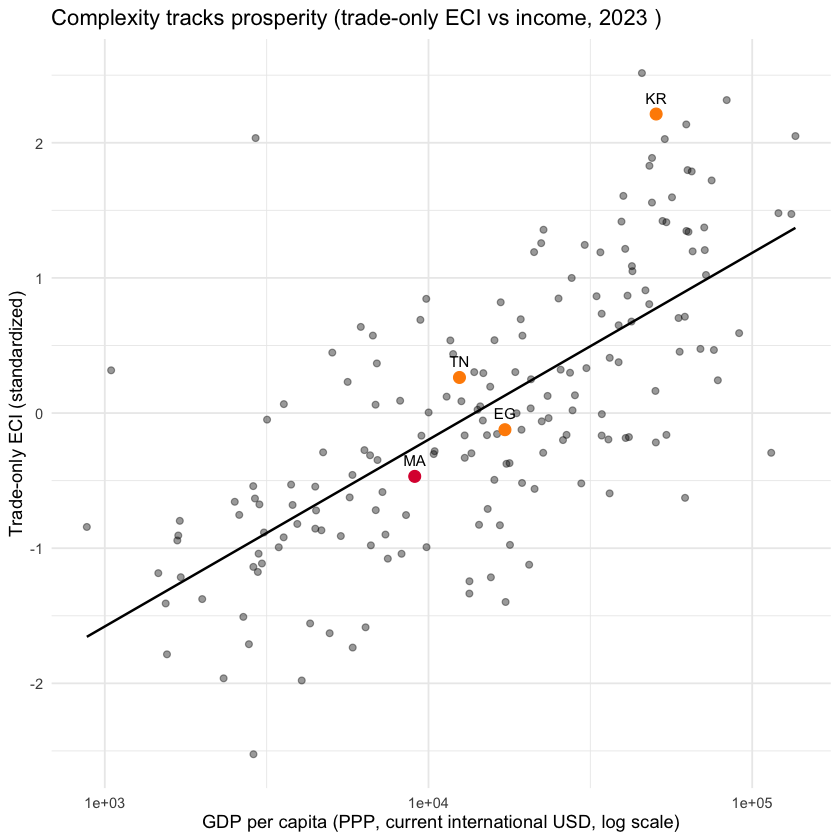

In [11]:
# Look up each country's GDP per capita, keyed by its code, then line it up with
# ECI. We build the frame with base data.frame and a distinctly named lookup
# vector, so the GDP column never shadows the vector it is computed from.
gdp_lookup <- setNames(units$`GDP PC`[units$Period == YEAR], units$Unit[units$Period == YEAR])
codes <- names(eci)
scatter <- data.frame(
  code = codes,
  eci = as.numeric(eci),
  gdp_pc = as.numeric(gdp_lookup[codes]),
  stringsAsFactors = FALSE
)
scatter <- scatter[!is.na(scatter$gdp_pc) & scatter$gdp_pc > 0, ]

corr <- cor(log(scatter$gdp_pc), scatter$eci)
cat("Correlation(log GDP per capita, ECI) =", round(corr, 3), "\n")

# Fit the simple regression explicitly, so the line in the plot has numbers behind
# it. We report the slope and the R^2.
fit <- lm(eci ~ log(gdp_pc), data = scatter)
slope <- coef(fit)[["log(gdp_pc)"]]
r2 <- summary(fit)$r.squared
cat("OLS slope (ECI on log GDP per capita) =", round(slope, 3), "| R^2 =", round(r2, 3), "\n")

highlight <- scatter[scatter$code %in% c(COUNTRY, COMPARATORS), ]
ggplot(scatter, aes(gdp_pc, eci)) +
  geom_point(alpha = 0.4, size = 1.6) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, color = "black", linewidth = 0.7) +
  geom_point(data = highlight, aes(color = code == COUNTRY), size = 3, show.legend = FALSE) +
  geom_text(data = highlight, aes(label = code), vjust = -1, size = 3.2) +
  scale_color_manual(values = c(`TRUE` = "#DC143C", `FALSE` = "darkorange")) +
  scale_x_log10() +
  labs(
    x = "GDP per capita (PPP, current international USD, log scale)",
    y = "Trade-only ECI (standardized)",
    title = paste("Complexity tracks prosperity (trade-only ECI vs income,", YEAR, ")")
  ) +
  theme_minimal()

In [12]:
# Self-check: the well-known positive relationship must hold. A negative or zero
# correlation would signal a pipeline error upstream.
if (!(corr > 0.4)) {
  stop("ECI should correlate positively with GDP per capita (r > 0.4). A weak value usually means a sign or eigenvector error.")
}
cat("OK: ECI and GDP per capita are positively related (r =", round(corr, 3), ").\n")

OK: ECI and GDP per capita are positively related (r = 0.697 ).


Across countries, ECI rises with income, the fitted line. Morocco sits a little below it here, so its trade-only ECI comes in slightly under what its income predicts. Read that position with care. This is a one-afternoon pipeline on trade data alone, with far less cleaning than the Atlas of Economic Complexity, so the exact distance from the line is not a basis for a growth claim. The takeaway is the positive slope, that more complex economies tend to be richer. Name one reason this simplified pipeline might place a country differently from the Atlas.

## What we learned

The `economiccomplexity` package reproduces the profile you built by hand. Morocco's diversity of 129, its RCA of 3.42 in Passenger Cars, its ECI near -0.47, and the same five highest-PCI products all come back from the package, and its ECI rank-matches the Python hand-roll almost perfectly. The package and your by-hand version agree because they compute the same thing, the second eigenvector of the reflection operator. The one real gap is against WIPO, near 0.92 rather than 1.0, and that gap is a difference of method rather than a mistake. Use the package when you want the numbers fast and audited; keep the by-hand version in mind so you always know what the package is doing.